In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

## a) plot kaplan meier curve by splitting groups (X < 2) and (X >= 2)

| Observation (Y ) | Censoring Indicator (δ) | Covariate (X) |
| --- | --- | --- |
| 26.5 | 1 | 0.1 |
| 37.2 | 1 | 11 |
| 57.3 | 1 | -0.3 |
| 90.8 | 0 | 2.8 |
| 20.2 | 0 | 1.8 |
| 89.8 | 0 | 0.4 |

In [11]:
group1 = [{"Observation (Y)" : 26.5, "Censoring Indicator (δ)" : 1, "Covariate (X)": 0.1}, 
          {"Observation (Y)" : 57.3, "Censoring Indicator (δ)" : 1, "Covariate (X)": -0.3},
          {"Observation (Y)" : 20.2, "Censoring Indicator (δ)" : 0, "Covariate (X)": 1.8},
          {"Observation (Y)" : 89.8, "Censoring Indicator (δ)" : 0, "Covariate (X)": 0.4}
]


group2 = [{"Observation (Y)" : 37.2, "Censoring Indicator (δ)" : 1, "Covariate (X)": 11}, 
          {"Observation (Y)" : 90.8, "Censoring Indicator (δ)" : 0, "Covariate (X)": -2.8}
]

df1 = pd.DataFrame(group1)
df2 = pd.DataFrame(group2)

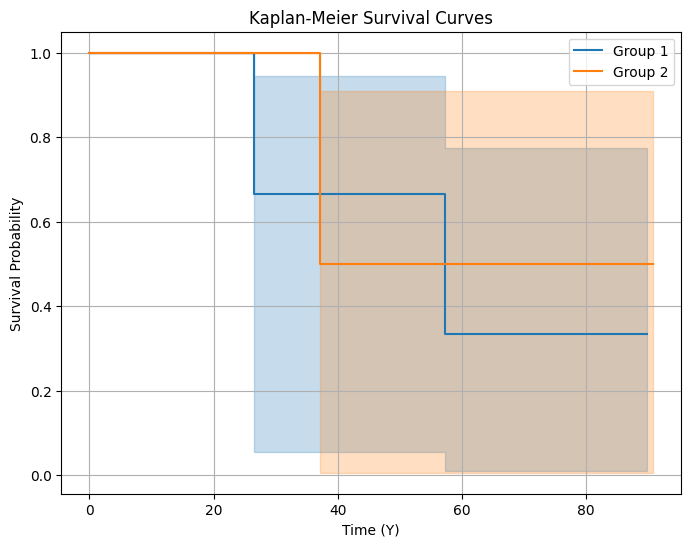

In [16]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8, 6))

kmf.fit(durations=df1["Observation (Y)"], 
        event_observed=df1["Censoring Indicator (δ)"], 
        label="Group 1")
kmf.plot_survival_function()

kmf.fit(durations=df2["Observation (Y)"], 
        event_observed=df2["Censoring Indicator (δ)"], 
        label="Group 2")
kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curves")
plt.xlabel("Time (Y)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

## b) Cox proportional hazards model

In [17]:
from lifelines import CoxPHFitter

# 1. Combine data and add a 'Group' indicator
df1['Group'] = 0
df2['Group'] = 1
df_combined = pd.concat([df1, df2])

# We only need the Duration (Y), Event (δ), and the Group indicator
# Note: You can also include 'Covariate (X)' if you want to control for it
data = df_combined[['Observation (Y)', 'Censoring Indicator (δ)', 'Group']]

# 2. Fit the Cox Model
cph = CoxPHFitter()
cph.fit(data, duration_col='Observation (Y)', event_col='Censoring Indicator (δ)')

# 3. View the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 6 total observations, 3 right-censored observations>
             duration col = 'Observation (Y)'
                event col = 'Censoring Indicator (δ)'
      baseline estimation = breslow
   number of observations = 6
number of events observed = 3
   partial log-likelihood = -4.06
         time fit was run = 2026-07-09 03:21:17 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Group     -0.34      0.71      1.24           -2.76            2.08                0.06                8.02

           cmp to     z    p  -log2(p)
covariate                             
Group        0.00 -0.28 0.78      0.35
---
Concordance = 0.50
Partial AIC = 10.11
log-likelihood ratio test = 0.08 on 1 df
-log2(p) of ll-ratio test = 0.36

In [18]:
from lifelines.statistics import logrank_test

# Extract durations and events for each group
durations_g1 = df1["Observation (Y)"]
events_g1 = df1["Censoring Indicator (δ)"]

durations_g2 = df2["Observation (Y)"]
events_g2 = df2["Censoring Indicator (δ)"]

# Conduct the Log-Rank Test
results = logrank_test(durations_g1, durations_g2, 
                       event_observed_A=events_g1, 
                       event_observed_B=events_g2)

print(f"Test Statistic: {results.test_statistic:.4f}")
print(f"p-value: {results.p_value:.4f}")

Test Statistic: 0.0764
p-value: 0.7822
